# Multithreading and Multitasking in Python

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import urllib
import os
import time

#### Code profiling

In [1]:
#! pip install line_profiler
%load_ext line_profiler

In [2]:
def sum_of_lists(N):
    total = 0
    for i in range(5):
        L = [j ^ (j >> i) for j in range(N)]
        total += sum(L)
    return total

In [3]:
%lprun -f sum_of_lists sum_of_lists(50)

In [45]:
def sum_of_lists_numpy(N):
    total = 0
    for i in range(5):
        L = np.array([j ^ (j >> i) for j in range(N)])
        total += np.sum(L)
    return total

In [46]:
%lprun -f sum_of_lists_numpy sum_of_lists_numpy(50)

#### MT and MP 
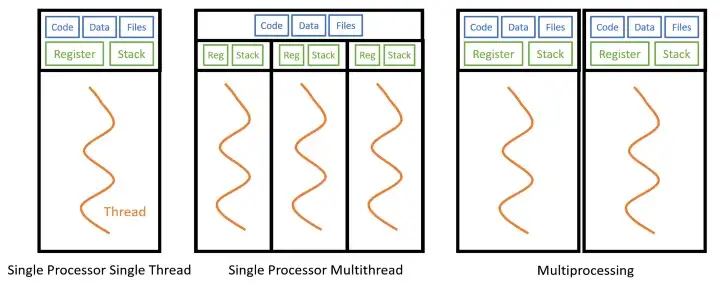
Source: https://towardsdatascience.com/multithreading-and-multiprocessing-in-10-minutes-20d9b3c6a867

#### Magic commands
https://ipython.readthedocs.io/en/stable/interactive/magics.html

In [ ]:
import threading
import multiprocessing

In [ ]:
def sum_range(start, end):
    total = 0
    for i in range(start, end):
        total += i
    return total

In [103]:
# decrease or increase n and see what happens
n = 25000
# n = 25000000

In [104]:
%%timeit

# Multithreading example
threads = []
for i in range(4):
    thread = threading.Thread(target=sum_range, args=(i*n, (i+1)*n))
    thread.start()
    threads.append(thread)

# Wait for all threads to complete
for thread in threads:
    thread.join()

4.81 s ± 249 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [105]:
%%timeit

# Multiprocessing example
processes = []
for i in range(4):
    process = multiprocessing.Process(target=sum_range, args=(i*n, (i+1)*n))
    process.start()
    processes.append(process)

# Wait for all processes to complete
for process in processes:
    process.join()

121 ms ± 21.6 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


#### I/O bound task

In [133]:
from multiprocessing.dummy import Pool as ThreadPool

In [32]:
urls = [
  'http://www.python.org',
  'http://www.python.org/about/',
  'http://www.onlamp.com/pub/a/python/2003/04/17/metaclasses.html',
  'http://www.python.org/doc/',
  'http://www.python.org/download/',
  'http://www.python.org/getit/',
  'http://www.python.org/community/',
  'https://wiki.python.org/moin/',
  'http://planet.python.org/',
  'https://wiki.python.org/moin/LocalUserGroups',
  'http://www.python.org/psf/',
  'http://docs.python.org/devguide/',
  'http://www.python.org/community/awards/'
  ]

In [70]:
%%timeit -n1 -r3

# Use one thread
results = []
for url in urls:
    result = urllib.request.urlopen(url)
    results.append(result)

3.14 s ± 36.5 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)


In [79]:
%%timeit -n1 -r3

# Use ThreadPool but with only one thread
pool = ThreadPool(1)
pool.map(urllib.request.urlopen, urls)

3.06 s ± 61.4 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)


In [125]:
%%timeit -n1 -r3

# Use ThreadPool with multiple threads
pool = ThreadPool(4)
pool.map(urllib.request.urlopen, urls)

1.37 s ± 37 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)


Text(0, 0.5, 'Time [s]')

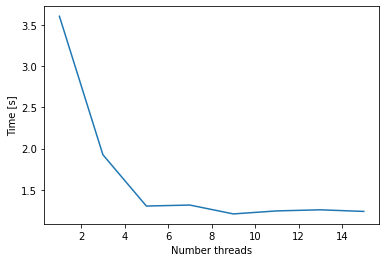

In [69]:
nb_threads = np.arange(1, 16, 2)
times = []

for nb_t in nb_threads:
    pool = ThreadPool(nb_t)
    t0 = time.time()
    pool.map(urllib.request.urlopen, urls)
    t1 = time.time()def sum_range(start, end):
    total = 0
    for i in range(start, end):
        total += i
    return total

    times.append(t1- t0)
    
plt.plot(nb_threads, times)
plt.xlabel("Number threads")
plt.ylabel("Time [s]")

### concurrent.futures
https://docs.python.org/3/library/concurrent.futures.html#module-concurrent.futures

Using this for the previous example:

In [ ]:
%%timeit -n1 -r3
with concurrent.futures.ProcessPoolExecutor(max_workers=10) as executor:
    results = executor.map(urllib.request.urlopen, urls)

Another example

In [30]:
import concurrent.futures
import flammkuchen as fl

In [114]:
os.mkdir("flammkuchen_files")

In [107]:
def save_array(array, idx):
    fl.save(f"flammkuchen_files/fl_{idx}.dsss", array)

In [110]:
arrays_with_idx = []
for i in range(10):
    arrays_with_idx.append((np.random.uniform(size=(10, 1024, 1024, 3)), i))

In [120]:
%%timeit -n1 -r1
for array, idx in arrays_with_idx:
    save_array(array, idx)

52.9 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [119]:
%%timeit -n1 -r1
with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
    executor.map(lambda f: save_array(*f), arrays_with_idx)

51.5 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [118]:
%%timeit -n1 -r1
with concurrent.futures.ProcessPoolExecutor(max_workers=10) as executor:
    executor.map(lambda f: save_array(*f), arrays_with_idx)

286 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


### Ray

https://github.com/ray-project/ray

https://towardsdatascience.com/modern-parallel-and-distributed-python-a-quick-tutorial-on-ray-99f8d70369b8

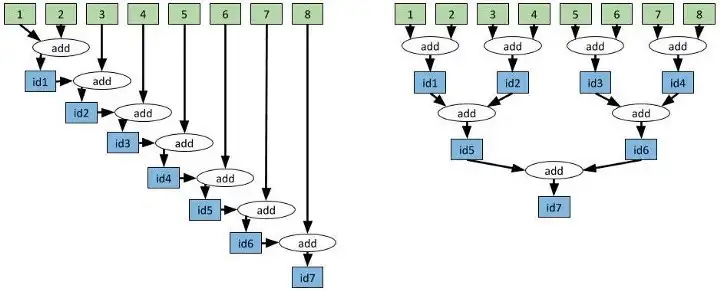

In [9]:
import ray  #!pip install ray
import time

In [14]:
@ray.remote
def add(x, y):
    return x + y

In [19]:
%%timeit
id1 = add.remote(1, 2)
id2 = add.remote(id1, 3)
id3 = add.remote(id2, 4)
id4 = add.remote(id3, 5)
id5 = add.remote(id4, 6)
id6 = add.remote(id5, 7)
id7 = add.remote(id6, 8)
result = ray.get(id7)

7.4 ms ± 514 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [20]:
%%timeit
id1 = add.remote(1, 2)
id2 = add.remote(3, 4)
id3 = add.remote(5, 6)
id4 = add.remote(7, 8)
id5 = add.remote(id1, id2)
id6 = add.remote(id3, id4)
id7 = add.remote(id5, id6)
result = ray.get(id7)

4.28 ms ± 101 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
